# freezing 8 10 23 OneOnOne

# lets plot neural trajectores in 2D PC SPACE

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *

import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA


%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
pre=100
post=52
sigma=10
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'

session = MPOptoClass(session_path, pre=pre,  post=post)

/home/diya/Documents/mp_opto/src/helpers/load.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  CFA['train'] = np.array((CFA['train']))
/home/diya/Documents/mp_opto/src/helpers/load.py:30: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  RFA['train'] = np.array((RFA['train']))


love


In [3]:
CFA_climbPCAobj, RFA_climbPCAobj = session.apply_PCA(bounds=session.climbing_bounds, sigma=sigma)

# 0. lets first just plot control trials, get a sense of how different trajectories are for these small 100 ms timewindows

In [4]:
CFA_ctrls, RFA_ctrls = session.smoother(bounds=session.ctrl_bounds[:, 2:], sigma=sigma, concat=True)

In [5]:
c_temp = CFA_climbPCAobj.transform(CFA_ctrls)
CFA_ctrl_PCA = unstitchBounds(c_temp, session.ctrl_bounds[:,2:])
r_temp = RFA_climbPCAobj.transform(RFA_ctrls)
RFA_ctrl_PCA = unstitchBounds(r_temp, session.ctrl_bounds[:,2:])

num_ctrls = CFA_ctrl_PCA.shape[2]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


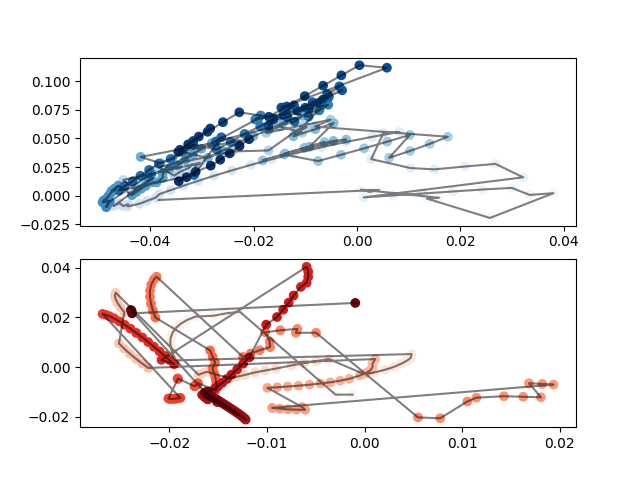

In [10]:
fig0, ax0 = plt.subplots(2,1)
#lets plot a random trajectory
random_pair = random.sample(range(0, num_ctrls), 1)


CFA_X = CFA_ctrl_PCA[:,0,random_pair]
CFA_Y = CFA_ctrl_PCA[:,1,random_pair]
RFA_X = RFA_ctrl_PCA[:,0,random_pair]
RFA_Y = RFA_ctrl_PCA[:,1,random_pair]

t=np.arange(CFA_X.shape[0])

ax0[0].plot(CFA_X, CFA_Y, '-', color='black', alpha=0.5)
ax0[0].scatter(CFA_X, CFA_Y, c=t, cmap='Blues')

ax0[1].plot(RFA_X, RFA_Y, '-', color='black', alpha=0.5)
ax0[1].scatter(RFA_X, RFA_Y, c=t, cmap='Reds')

# 1. what influence does this have on the trajectories

In [7]:
CFA_trials, RFA_trials = session.smoother(bounds=session.laser_bounds[:, 2:], sigma=sigma, concat=True)

c_temp = CFA_climbPCAobj.transform(CFA_trials)
CFA_trial_PCA = unstitchBounds(c_temp, session.laser_bounds[:,2:])
r_temp = RFA_climbPCAobj.transform(RFA_trials)
RFA_trial_PCA = unstitchBounds(r_temp, session.laser_bounds[:,2:])

num_trials = CFA_trial_PCA.shape[2]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


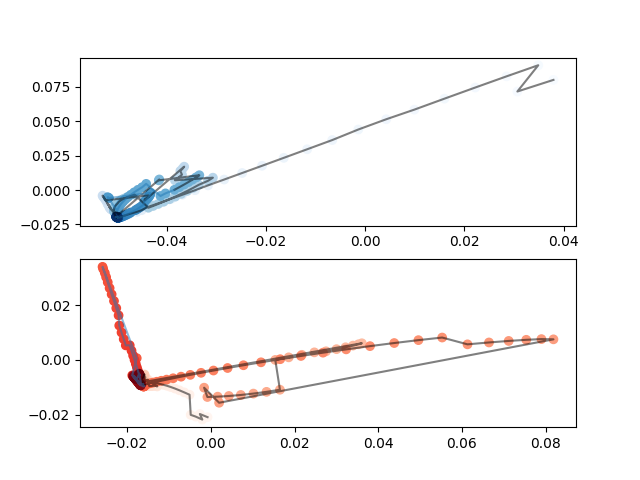

In [8]:
fig1, ax1= plt.subplots(2,1)
#lets plot a random trajectory
random_pair = random.sample(range(0, num_trials), 1)


CFA_X = CFA_trial_PCA[:,0,random_pair]
CFA_Y = CFA_trial_PCA[:,1,random_pair]
RFA_X = RFA_trial_PCA[:,0,random_pair]
RFA_Y = RFA_trial_PCA[:,1,random_pair]

t=np.arange(CFA_X.shape[0])

ax1[0].plot(CFA_X[:pre], CFA_Y[:pre], '-', color='black', alpha=0.5)
ax1[0].plot(CFA_X[pre-1:], CFA_Y[pre-1:], '-', color='tab:blue', alpha=0.5)
ax1[0].scatter(CFA_X, CFA_Y, c=t, cmap='Blues')

ax1[1].plot(RFA_X[:pre], RFA_Y[:pre], '-', color='black', alpha=0.5)
ax1[1].plot(RFA_X[pre-1:], RFA_Y[pre-1:], '-', color='tab:blue', alpha=0.5)
ax1[1].scatter(RFA_X, RFA_Y, c=t, cmap='Reds')